# Notebook 1 · Introductory Implementation of Quantum-Enhanced Markowitz Portfolio Optimization

**Audience:** M.Tech students · Quantum Computing beginners · BFSI professionals
**Prerequisites:** Basic linear algebra, Python, introductory probability
**Environment:** Python 3.11 · Qiskit 1.x · qiskit-optimization · qiskit-algorithms · NumPy · SciPy · Matplotlib

---

## Learning Objectives
1. Understand Modern Portfolio Theory (MPT) and the Markowitz mean-variance framework.
2. Formulate and solve the classical portfolio optimization problem.
3. Convert the portfolio problem into a **Quadratic Unconstrained Binary Optimization (QUBO)** problem.
4. Solve the QUBO using **Qiskit Optimization** with a classical exact solver and compare results.
5. Visualize the efficient frontier and the selected portfolio.

> **Note on Quantum Hardware:** This notebook uses `NumPyMinimumEigensolver` (exact classical) to produce verifiable results.
> Notebooks 2_1 and 2_2 replace this with QAOA/VQE/QAE on a simulator.


## Package Imports

In [1]:
# ── Standard scientific stack ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

# ── Qiskit Optimization stack ──────────────────────────────────────────────
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.converters import QuadraticProgramToQubo
from qiskit_optimization.algorithms import MinimumEigenOptimizer

# ── Qiskit Algorithms (exact classical eigensolver) ───────────────────────
from qiskit_algorithms import NumPyMinimumEigensolver

# ── Plot style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})
print("All imports successful.")
print(f"  NumPy      : {np.__version__}")
import qiskit; print(f"  Qiskit     : {qiskit.__version__}")
import qiskit_optimization; print(f"  qiskit-opt : {qiskit_optimization.__version__}")
import qiskit_algorithms;   print(f"  qiskit-alg : {qiskit_algorithms.__version__}")


All imports successful.
  NumPy      : 2.2.6
  Qiskit     : 1.3.0
  qiskit-opt : 0.6.1
  qiskit-alg : 0.3.1


---
## Section 1 · Introduction to Modern Portfolio Theory

### 1.1 Historical Background

Harry Markowitz (1952) revolutionised finance with a simple but powerful insight:

> **"Diversification reduces risk without necessarily reducing expected return."**

Before Markowitz, investors evaluated assets in isolation. He showed that what matters is the **joint behaviour** (correlation) of assets, not just individual risk/return.

### 1.2 Core Idea

Given $n$ risky assets, we search for the portfolio weights $\mathbf{w} = [w_1, w_2, \ldots, w_n]^T$ that achieve the best possible **risk–return trade-off**.

| Quantity | Symbol | Meaning |
|---|---|---|
| Expected return | $\boldsymbol{\mu}$ | $\mu_i = \mathbb{E}[r_i]$ |
| Covariance matrix | $\boldsymbol{\Sigma}$ | $\Sigma_{ij} = \text{Cov}(r_i, r_j)$ |
| Portfolio return | $\mu_p$ | $\boldsymbol{\mu}^T \mathbf{w}$ |
| Portfolio variance | $\sigma_p^2$ | $\mathbf{w}^T \boldsymbol{\Sigma} \mathbf{w}$ |

### 1.3 The Efficient Frontier

The **efficient frontier** is the set of portfolios that minimise variance for each level of expected return. It is a parabola in mean-variance space.

$$\sigma_p^2 = \mathbf{w}^T \boldsymbol{\Sigma} \mathbf{w}, \qquad \mu_p = \boldsymbol{\mu}^T \mathbf{w}$$

Portfolios **on** the frontier dominate portfolios **below** it.


---
## Section 2 · Classical Markowitz Formulation

### 2.1 Continuous Optimisation Problem

$$\boxed{\min_{\mathbf{w}} \quad \mathbf{w}^T \boldsymbol{\Sigma} \mathbf{w}}$$

subject to:

$$\boldsymbol{\mu}^T \mathbf{w} \geq R_{\text{target}}, \qquad \sum_{i=1}^n w_i = 1, \qquad w_i \geq 0$$

where:
- $\mathbf{w} \in \mathbb{R}^n$ are **continuous** portfolio weights (long-only constraint $w_i \geq 0$).
- $\boldsymbol{\Sigma} \in \mathbb{R}^{n \times n}$ is the **positive semi-definite** covariance matrix.
- $R_{\text{target}}$ is the minimum acceptable expected return.

### 2.2 Why Is This Hard at Scale?

| Assets $n$ | Covariance entries $n^2$ | Optimisation variables |
|---|---|---|
| 10 | 100 | 10 |
| 500 | 250,000 | 500 |
| 5,000 | 25,000,000 | 5,000 |

For **cardinality constraints** (select exactly $k$ assets), the problem becomes **NP-hard**:

$$\sum_{i=1}^n \mathbb{1}[w_i > 0] = k$$

This integer constraint makes classical solvers exponentially slow as $n$ grows.

### 2.3 The Quantum Opportunity

Quantum optimisers (QAOA, VQE, Quantum Annealing) can explore $2^n$ binary combinations **simultaneously** via superposition, offering a potential exponential speedup for the cardinality-constrained version.


---
## Section 3 · Generate Synthetic Asset Returns

We simulate **5 assets** with controlled expected returns and correlations.
Using synthetic data ensures reproducibility and allows us to verify the quantum solution against an exact classical solution.


Daily return statistics (annualised):
         Ann. Mean (%)  Ann. Std  (%)
ALPHA            22.29          14.49
BETA             28.47          25.28
GAMMA            16.23          11.63
DELTA            23.73          28.46
EPSILON          42.17          19.96


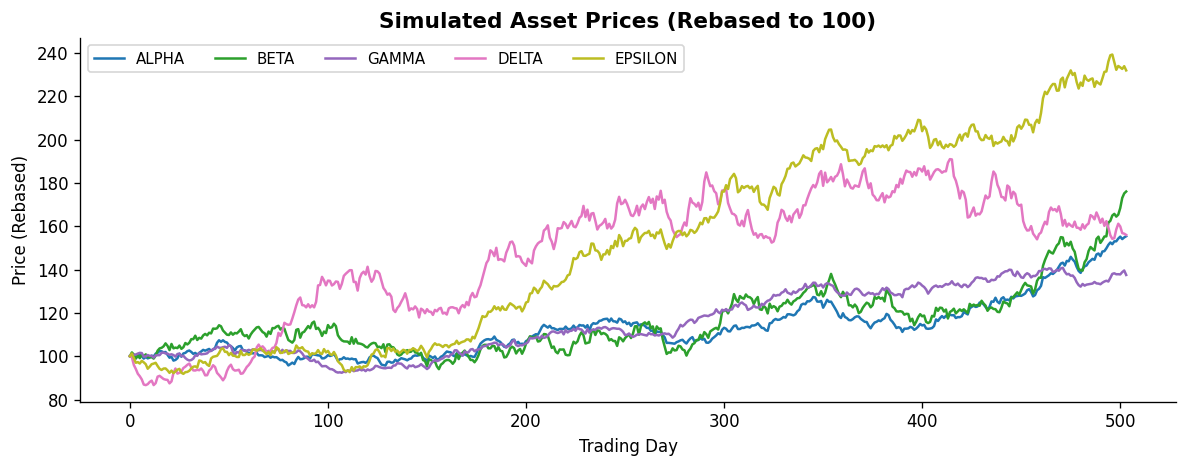

In [2]:
np.random.seed(42)          # reproducibility

N_ASSETS  = 5               # number of assets
N_DAYS    = 504             # ~2 years of trading days
ASSET_NAMES = ["ALPHA", "BETA", "GAMMA", "DELTA", "EPSILON"]

# ── 1. Define ground-truth annual parameters ──────────────────────────────
annual_mu    = np.array([0.12, 0.18, 0.10, 0.22, 0.15])   # expected annual returns
annual_sigma = np.array([0.15, 0.25, 0.12, 0.30, 0.20])   # annual volatilities

# ── 2. Build a realistic correlation matrix ───────────────────────────────
# Off-diagonal correlations represent realistic inter-asset dependencies
corr = np.array([
    [1.00,  0.65,  0.30,  0.10,  0.50],
    [0.65,  1.00,  0.20,  0.15,  0.60],
    [0.30,  0.20,  1.00,  0.05,  0.25],
    [0.10,  0.15,  0.05,  1.00,  0.12],
    [0.50,  0.60,  0.25,  0.12,  1.00],
])

# ── 3. Derive covariance matrix: Σ = D·ρ·D  (D = diag(σ)) ─────────────────
D   = np.diag(annual_sigma)
COV = D @ corr @ D          # annual covariance matrix

# ── 4. Simulate daily log-returns using Cholesky decomposition ────────────
dt            = 1 / 252                          # one trading day
mu_daily      = annual_mu * dt
sigma_daily   = annual_sigma * np.sqrt(dt)

# Cholesky factor for correlated sampling
L = np.linalg.cholesky(corr)

Z        = np.random.randn(N_DAYS, N_ASSETS)     # standard normal shocks
Z_corr   = Z @ L.T                               # correlated shocks

# Daily log returns: r_t = (μ - σ²/2)dt + σ√dt·Z
daily_returns = (mu_daily - 0.5 * sigma_daily**2) + sigma_daily * Z_corr

# ── 5. Build price series ─────────────────────────────────────────────────
prices = pd.DataFrame(
    100 * np.exp(np.cumsum(daily_returns, axis=0)),
    columns=ASSET_NAMES
)
prices.index.name = "Day"

print("Daily return statistics (annualised):")
print(pd.DataFrame({
    "Ann. Mean (%)": (daily_returns.mean(0) * 252 * 100).round(2),
    "Ann. Std  (%)": (daily_returns.std(0)  * np.sqrt(252) * 100).round(2),
}, index=ASSET_NAMES))

# ── 6. Plot simulated prices ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
colors = plt.cm.tab10(np.linspace(0, 0.8, N_ASSETS))
for i, col in enumerate(prices.columns):
    ax.plot(prices[col] / prices[col].iloc[0] * 100,
            label=col, color=colors[i], lw=1.5)
ax.set_title("Simulated Asset Prices (Rebased to 100)", fontsize=13, fontweight="bold")
ax.set_xlabel("Trading Day"); ax.set_ylabel("Price (Rebased)")
ax.legend(ncol=5, fontsize=9)
plt.tight_layout(); plt.show()


---
## Section 4 · Compute Expected Returns and Covariance Matrix

From the simulated daily returns we estimate:

$$\hat{\mu}_i = \frac{1}{T}\sum_{t=1}^T r_{i,t} \times 252 \quad \text{(annualised)}$$

$$\hat{\Sigma}_{ij} = \frac{1}{T-1}\sum_{t=1}^T (r_{i,t} - \hat{\mu}_i)(r_{j,t} - \hat{\mu}_j) \times 252$$

The covariance matrix must be **positive semi-definite** (PSD) for the optimisation to be convex.
We verify PSD by checking that all eigenvalues are $\geq 0$.


Covariance matrix eigenvalues: [0.008937 0.01416  0.019555 0.074934 0.102149]
PSD check (all eigenvalues >= 0): True

Expected Returns:
         Expected Return (%)
ALPHA                  22.29
BETA                   28.47
GAMMA                  16.23
DELTA                  23.73
EPSILON                42.17

Covariance Matrix:
          ALPHA    BETA   GAMMA   DELTA  EPSILON
ALPHA    0.0210  0.0228  0.0059  0.0052   0.0136
BETA     0.0228  0.0641  0.0069  0.0089   0.0306
GAMMA    0.0059  0.0069  0.0136  0.0019   0.0065
DELTA    0.0052  0.0089  0.0019  0.0812   0.0049
EPSILON  0.0136  0.0306  0.0065  0.0049   0.0399


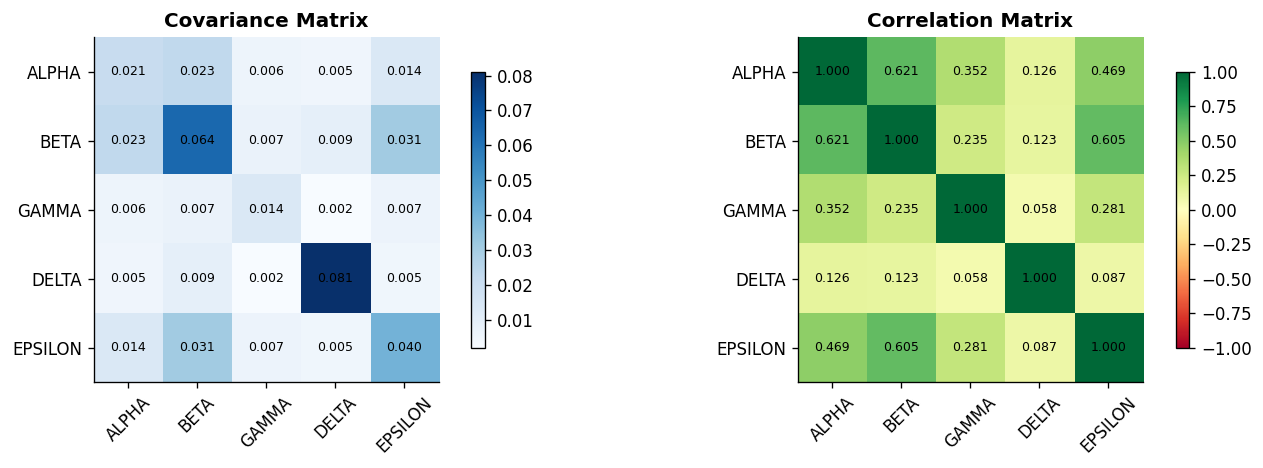

In [3]:
# ── Annualised expected returns ────────────────────────────────────────────
mu_ann  = daily_returns.mean(0) * 252          # vector of expected returns
cov_ann = np.cov(daily_returns, rowvar=False) * 252   # annualised covariance

# ── Verify positive semi-definiteness ─────────────────────────────────────
eigenvalues = np.linalg.eigvalsh(cov_ann)
print("Covariance matrix eigenvalues:", np.round(eigenvalues, 6))
print(f"PSD check (all eigenvalues >= 0): {np.all(eigenvalues >= -1e-10)}")

# ── Pretty-print ──────────────────────────────────────────────────────────
mu_df  = pd.DataFrame({"Expected Return (%)": mu_ann * 100}, index=ASSET_NAMES).round(2)
cov_df = pd.DataFrame(cov_ann, index=ASSET_NAMES, columns=ASSET_NAMES).round(4)
print("\nExpected Returns:"); print(mu_df)
print("\nCovariance Matrix:"); print(cov_df)

# ── Visualise correlation heatmap ─────────────────────────────────────────
std_vec  = np.sqrt(np.diag(cov_ann))
corr_est = cov_ann / np.outer(std_vec, std_vec)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im1 = axes[0].imshow(cov_ann,  cmap="Blues")
im2 = axes[1].imshow(corr_est, cmap="RdYlGn", vmin=-1, vmax=1)

for ax, mat, title in zip(axes, [cov_ann, corr_est], ["Covariance Matrix", "Correlation Matrix"]):
    ax.set_xticks(range(N_ASSETS)); ax.set_xticklabels(ASSET_NAMES, rotation=45)
    ax.set_yticks(range(N_ASSETS)); ax.set_yticklabels(ASSET_NAMES)
    ax.set_title(title, fontsize=12, fontweight="bold")
    for i in range(N_ASSETS):
        for j in range(N_ASSETS):
            ax.text(j, i, f"{mat[i,j]:.3f}", ha="center", va="center", fontsize=7.5)

plt.colorbar(im1, ax=axes[0], shrink=0.8)
plt.colorbar(im2, ax=axes[1], shrink=0.8)
plt.tight_layout(); plt.show()


---
## Section 5 · Classical Optimisation Using SciPy

We solve the continuous Markowitz problem with `scipy.optimize.minimize` using the **SLSQP** method (Sequential Least Squares Programming), which handles equality and inequality constraints natively.

We sweep over $R_{\text{target}}$ values to trace the **efficient frontier**.


In [4]:
def portfolio_variance(w, cov):
    # Portfolio variance: w^T Sigma w
    return w @ cov @ w

def portfolio_return(w, mu):
    # Portfolio expected return: mu^T w
    return mu @ w

def portfolio_sharpe(w, mu, cov, rf=0.03):
    # Sharpe ratio: (mu_p - r_f) / sigma_p
    ret = portfolio_return(w, mu)
    std = np.sqrt(portfolio_variance(w, cov))
    return (ret - rf) / std if std > 1e-9 else 0.0

def solve_markowitz(mu, cov, R_target, allow_short=False):
    # Solve Markowitz mean-variance: minimise variance subject to return >= R_target
    # mu          : array (n,)  expected returns
    # cov         : array (n,n) covariance matrix
    # R_target    : float       minimum target return
    # allow_short : bool        if False, w_i >= 0 (long-only)
    n = len(mu)
    w0 = np.ones(n) / n   # equal-weight starting point

    constraints = [
        {"type": "eq",   "fun": lambda w: np.sum(w) - 1},          # budget
        {"type": "ineq", "fun": lambda w: mu @ w - R_target},       # return floor
    ]
    bounds = [(0, 1)] * n if not allow_short else [(-1, 1)] * n

    result = minimize(
        fun=portfolio_variance,
        x0=w0,
        args=(cov,),
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"ftol": 1e-12, "maxiter": 1000},
    )
    return result

# ── Sweep R_target to trace efficient frontier ────────────────────────────
R_min  = mu_ann.min() * 1.01
R_max  = mu_ann.max() * 0.99
R_vals = np.linspace(R_min, R_max, 120)

ef_returns  = []
ef_variances = []
ef_weights  = []

for R in R_vals:
    res = solve_markowitz(mu_ann, cov_ann, R)
    if res.success:
        ef_returns.append(portfolio_return(res.x, mu_ann))
        ef_variances.append(portfolio_variance(res.x, cov_ann))
        ef_weights.append(res.x)

ef_returns   = np.array(ef_returns)
ef_variances = np.array(ef_variances)
ef_stds      = np.sqrt(ef_variances)

# ── Maximum Sharpe Ratio portfolio ────────────────────────────────────────
sharpes  = [(portfolio_return(w, mu_ann) - 0.03) / np.sqrt(portfolio_variance(w, cov_ann))
            for w in ef_weights]
max_idx  = np.argmax(sharpes)
msr_w    = ef_weights[max_idx]

# ── Minimum Variance portfolio ────────────────────────────────────────────
min_var_idx = np.argmin(ef_variances)
mvp_w = ef_weights[min_var_idx]

print("=" * 50)
print("CLASSICAL OPTIMISATION RESULTS")
print("=" * 50)

for label, w in [("Max Sharpe", msr_w), ("Min Variance", mvp_w)]:
    ret = portfolio_return(w, mu_ann)
    std = np.sqrt(portfolio_variance(w, cov_ann))
    shr = (ret - 0.03) / std
    print(f"\n{label} Portfolio:")
    print(f"  Weights     : {dict(zip(ASSET_NAMES, np.round(w, 4)))}")
    print(f"  Return      : {ret*100:.2f}%")
    print(f"  Volatility  : {std*100:.2f}%")
    print(f"  Sharpe Ratio: {shr:.3f}")


CLASSICAL OPTIMISATION RESULTS

Max Sharpe Portfolio:
  Weights     : {'ALPHA': np.float64(0.13), 'BETA': np.float64(0.0), 'GAMMA': np.float64(0.2749), 'DELTA': np.float64(0.1084), 'EPSILON': np.float64(0.4867)}
  Return      : 30.46%
  Volatility  : 12.83%
  Sharpe Ratio: 2.139

Min Variance Portfolio:
  Weights     : {'ALPHA': np.float64(0.2536), 'BETA': np.float64(0.0), 'GAMMA': np.float64(0.5964), 'DELTA': np.float64(0.091), 'EPSILON': np.float64(0.059)}
  Return      : 19.98%
  Volatility  : 10.08%
  Sharpe Ratio: 1.685


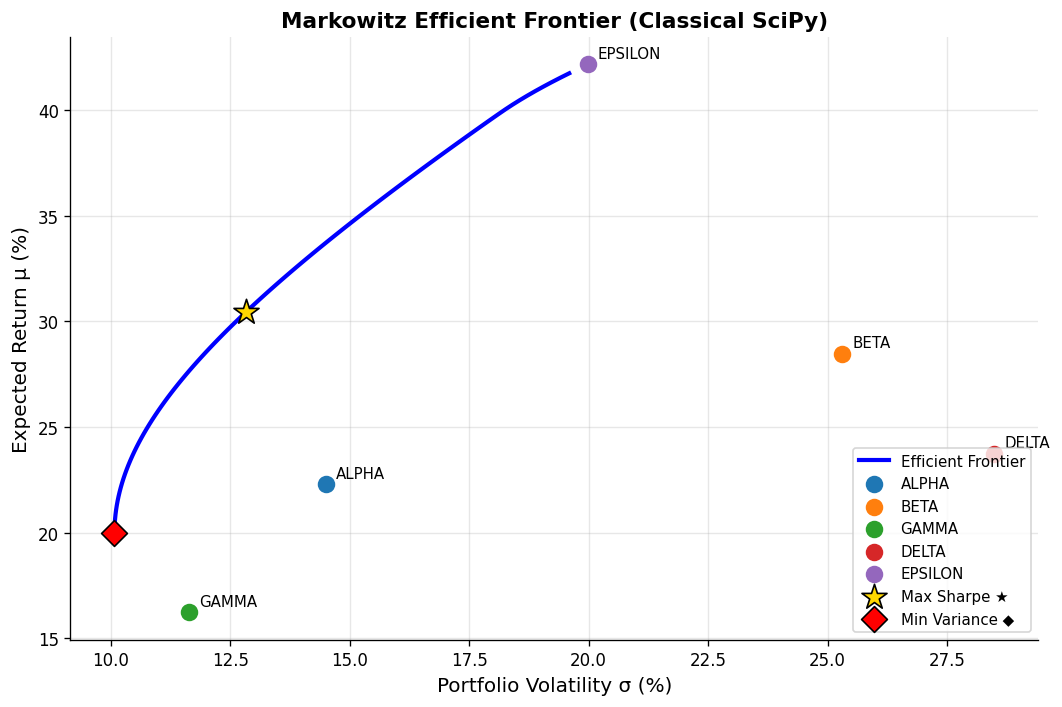

In [5]:
# ── Plot efficient frontier ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

# Efficient frontier curve
ax.plot(ef_stds * 100, ef_returns * 100, "b-", lw=2.5, label="Efficient Frontier")

# Individual assets
for i in range(N_ASSETS):
    ax.scatter(
        np.sqrt(cov_ann[i, i]) * 100,
        mu_ann[i] * 100,
        s=90, zorder=5, label=ASSET_NAMES[i]
    )
    ax.annotate(
        ASSET_NAMES[i],
        (np.sqrt(cov_ann[i, i]) * 100, mu_ann[i] * 100),
        xytext=(6, 4), textcoords="offset points", fontsize=9
    )

# Special portfolios
ax.scatter(ef_stds[max_idx]*100, ef_returns[max_idx]*100,
           marker="*", s=250, color="gold", edgecolors="k", zorder=6, label="Max Sharpe ★")
ax.scatter(ef_stds[min_var_idx]*100, ef_returns[min_var_idx]*100,
           marker="D", s=120, color="red", edgecolors="k", zorder=6, label="Min Variance ◆")

ax.set_xlabel("Portfolio Volatility σ (%)", fontsize=12)
ax.set_ylabel("Expected Return μ (%)", fontsize=12)
ax.set_title("Markowitz Efficient Frontier (Classical SciPy)", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## Section 6 · QUBO Formulation

### 6.1 From Continuous to Binary

Quantum optimisers operate on **binary variables** $x_i \in \{0, 1\}$, where:

$$x_i = 1 \implies \text{asset } i \text{ is selected}$$
$$x_i = 0 \implies \text{asset } i \text{ is not selected}$$

We select exactly $B$ (budget) assets from $n$ available.

### 6.2 Objective Function

The portfolio objective (risk minus return) in binary form:

$$\mathcal{L}(\mathbf{x}) = q \sum_{i,j} \Sigma_{ij} x_i x_j - (1 - q) \sum_i \mu_i x_i$$

where $q \in [0,1]$ is the **risk-aversion parameter**.

### 6.3 Budget Constraint via Penalty

To enforce $\sum_i x_i = B$, we add a penalty term:

$$\mathcal{P}(\mathbf{x}) = A \left(\sum_i x_i - B\right)^2$$

The complete **QUBO objective** is:

$$\boxed{f(\mathbf{x}) = q \cdot \mathbf{x}^T \boldsymbol{\Sigma} \mathbf{x} - (1-q)\boldsymbol{\mu}^T \mathbf{x} + A\left(\sum_i x_i - B\right)^2}$$

This can be written as $f(\mathbf{x}) = \mathbf{x}^T Q \mathbf{x}$ (QUBO form) where $Q$ is derived from $\boldsymbol{\Sigma}$, $\boldsymbol{\mu}$, and $A$.

### 6.4 Penalty Parameter Choice

A common heuristic for $A$:

$$A > \frac{q \cdot \max_i \Sigma_{ii}}{2}$$

This ensures the penalty dominates when the constraint is violated.


In [6]:
# ── QUBO Parameters ───────────────────────────────────────────────────────
BUDGET      = 3       # select exactly 3 assets out of 5
RISK_FACTOR = 0.5     # q: balance between risk (1) and return (0)
PENALTY_A   = 5.0     # penalty weight for budget constraint

# ── Build Quadratic Program ───────────────────────────────────────────────
qp = QuadraticProgram(name="Markowitz_QUBO")

# Binary decision variable for each asset
for i, name in enumerate(ASSET_NAMES):
    qp.binary_var(name=f"x_{name}")

# ── Objective: minimise q * risk - (1-q) * return ────────────────────────
# Linear coefficients come from the return term: -(1-q)*mu_i
linear_coeffs = {f"x_{ASSET_NAMES[i]}": -(1 - RISK_FACTOR) * mu_ann[i]
                 for i in range(N_ASSETS)}

# Quadratic coefficients come from the risk term: q * Sigma_ij
quadratic_coeffs = {}
for i in range(N_ASSETS):
    for j in range(N_ASSETS):
        key = (f"x_{ASSET_NAMES[i]}", f"x_{ASSET_NAMES[j]}")
        quadratic_coeffs[key] = RISK_FACTOR * cov_ann[i, j]

qp.minimize(linear=linear_coeffs, quadratic=quadratic_coeffs)

# ── Budget constraint: sum(x_i) == BUDGET ────────────────────────────────
qp.linear_constraint(
    linear={f"x_{ASSET_NAMES[i]}": 1 for i in range(N_ASSETS)},
    sense="==",
    rhs=BUDGET,
    name="budget_constraint",
)

print("Quadratic Program:")
print(qp.export_as_lp_string())


Quadratic Program:
\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: Markowitz_QUBO

Minimize
 obj: - 0.111448975659 x_ALPHA - 0.142365083683 x_BETA - 0.081152880281 x_GAMMA
      - 0.118666295592 x_DELTA - 0.210858112840 x_EPSILON + [
      0.021030244653 x_ALPHA^2 + 0.045580501825 x_ALPHA*x_BETA
      + 0.011886476830 x_ALPHA*x_GAMMA + 0.010452104389 x_ALPHA*x_DELTA
      + 0.027175949570 x_ALPHA*x_EPSILON + 0.064051450849 x_BETA^2
      + 0.013867350975 x_BETA*x_GAMMA + 0.017785387627 x_BETA*x_DELTA
      + 0.061182840591 x_BETA*x_EPSILON + 0.013556593100 x_GAMMA^2
      + 0.003876266624 x_GAMMA*x_DELTA + 0.013087953461 x_GAMMA*x_EPSILON
      + 0.081166517680 x_DELTA^2 + 0.009880340833 x_DELTA*x_EPSILON
      + 0.039929412119 x_EPSILON^2 ]/2
Subject To
 budget_constraint: x_ALPHA + x_BETA + x_GAMMA + x_DELTA + x_EPSILON = 3

Bounds
 0 <= x_ALPHA <= 1
 0 <= x_BETA <= 1
 0 <= x_GAMMA <= 1
 0 <= x_DELTA <= 1
 0 <= x_EPSILON <= 1

Binaries
 x_ALPHA x_BETA x

In [7]:
# ── Convert to QUBO ───────────────────────────────────────────────────────
# QuadraticProgramToQubo automatically:
#   1. Replaces equality constraints with quadratic penalty terms
#   2. Substitutes remaining variables
#   3. Returns a pure QUBO (no constraints)
converter = QuadraticProgramToQubo()
qubo      = converter.convert(qp)

print("QUBO (after constraint elimination):")
print(qubo.export_as_lp_string())

# ── Inspect the QUBO Q-matrix ─────────────────────────────────────────────
# The full QUBO is: f(x) = x^T Q x  (with diagonal for linear terms)
n = N_ASSETS
Q_matrix = np.zeros((n, n))

for (i_key, j_key), val in qubo.objective.quadratic.to_dict(use_name=True).items():
    i = int(i_key.split("_")[1].replace("ALPHA","0").replace("BETA","1")
                               .replace("GAMMA","2").replace("DELTA","3")
                               .replace("EPSILON","4"))
    # Use variable index directly from the QUBO variable list
    pass  # (matrix shown below via pandas)

# Build Q matrix using variable indices
var_names = [v.name for v in qubo.variables]
var_idx   = {v: i for i, v in enumerate(var_names)}

Q_matrix  = np.zeros((n, n))
for (vi, vj), coeff in qubo.objective.quadratic.to_dict().items():
    Q_matrix[vi, vj] += coeff

for vi, coeff in qubo.objective.linear.to_dict().items():
    Q_matrix[vi, vi] += coeff

print("\nQ-matrix (QUBO):")
print(pd.DataFrame(Q_matrix, index=var_names, columns=var_names).round(4))


QUBO (after constraint elimination):
\ This file has been generated by DOcplex
\ ENCODING=ISO-8859-1
\Problem name: Markowitz_QUBO

Minimize
 obj: - 11.401925237367 x_ALPHA - 11.432841345391 x_BETA
      - 11.371629141988 x_GAMMA - 11.409142557300 x_DELTA
      - 11.501334374548 x_EPSILON + [ 3.784522331889 x_ALPHA^2
      + 7.572564676297 x_ALPHA*x_BETA + 7.538870651302 x_ALPHA*x_GAMMA
      + 7.537436278861 x_ALPHA*x_DELTA + 7.554160124042 x_ALPHA*x_EPSILON
      + 3.827543538085 x_BETA^2 + 7.540851525447 x_BETA*x_GAMMA
      + 7.544769562099 x_BETA*x_DELTA + 7.588167015063 x_BETA*x_EPSILON
      + 3.777048680336 x_GAMMA^2 + 7.530860441096 x_GAMMA*x_DELTA
      + 7.540072127933 x_GAMMA*x_EPSILON + 3.844658604916 x_DELTA^2
      + 7.536864515305 x_DELTA*x_EPSILON + 3.803421499355 x_EPSILON^2 ]/2 +
      16.935714392562
Subject To

Bounds
 0 <= x_ALPHA <= 1
 0 <= x_BETA <= 1
 0 <= x_GAMMA <= 1
 0 <= x_DELTA <= 1
 0 <= x_EPSILON <= 1

Binaries
 x_ALPHA x_BETA x_GAMMA x_DELTA x_EPSILON
E

---
## Section 7 · Solve QUBO Using Qiskit Optimization

We use `MinimumEigenOptimizer` wrapping `NumPyMinimumEigensolver`, which finds the exact ground state by diagonalising the QUBO Hamiltonian.

This is equivalent to brute-force enumeration of all $2^n$ binary strings — feasible for $n = 5$, but exponentially expensive for large $n$ (motivating quantum hardware).

**Quantum connection:** On a quantum computer, `NumPyMinimumEigensolver` is replaced by QAOA or VQE, which approximate the ground state efficiently.


In [8]:
# ── Exact Solver (classical, for verification) ────────────────────────────
numpy_solver     = NumPyMinimumEigensolver()
exact_optimizer  = MinimumEigenOptimizer(numpy_solver)

print("Solving QUBO with NumPyMinimumEigensolver (exact)...")
result = exact_optimizer.solve(qubo)

print("\n" + "="*50)
print("QUANTUM OPTIMISATION RESULT (Exact Classical)")
print("="*50)
print(f"Status        : {result.status.name}")
print(f"Objective     : {result.fval:.6f}")
print(f"Variable names: {var_names}")
print(f"Solution      : {result.x.astype(int)}")

selected = [ASSET_NAMES[i] for i, xi in enumerate(result.x) if xi > 0.5]
print(f"Selected assets ({BUDGET} of {N_ASSETS}): {selected}")


Solving QUBO with NumPyMinimumEigensolver (exact)...

QUANTUM OPTIMISATION RESULT (Exact Classical)
Status        : SUCCESS
Objective     : -0.346156
Variable names: ['x_ALPHA', 'x_BETA', 'x_GAMMA', 'x_DELTA', 'x_EPSILON']
Solution      : [1 0 0 1 1]
Selected assets (3 of 5): ['ALPHA', 'DELTA', 'EPSILON']


In [9]:
# ── Analyse selected portfolio ────────────────────────────────────────────
x_opt  = result.x.astype(int)
w_qubo = np.where(x_opt, 1.0 / BUDGET, 0.0)   # equal-weight among selected

ret_q  = portfolio_return(w_qubo, mu_ann)
var_q  = portfolio_variance(w_qubo, cov_ann)
std_q  = np.sqrt(var_q)
shr_q  = (ret_q - 0.03) / std_q

print("\n" + "-"*40)
print("Quantum-QUBO Selected Portfolio:")
print(f"  Selected assets    : {selected}")
print(f"  Equal weights      : {[f'{ASSET_NAMES[i]}: {w_qubo[i]:.2f}' for i in range(N_ASSETS) if w_qubo[i]>0]}")
print(f"  Expected Return    : {ret_q*100:.2f}%")
print(f"  Portfolio Std Dev  : {std_q*100:.2f}%")
print(f"  Sharpe Ratio       : {shr_q:.3f}")

# ── Brute force verification ──────────────────────────────────────────────
from itertools import combinations

best_obj = np.inf
best_combo = None
print("\nBrute-force check (all C(5,3)=10 combinations):")
for combo in combinations(range(N_ASSETS), BUDGET):
    w_bf = np.zeros(N_ASSETS)
    w_bf[list(combo)] = 1.0 / BUDGET
    x_bf = (w_bf > 0).astype(float)
    obj  = (RISK_FACTOR * x_bf @ cov_ann @ x_bf
            - (1-RISK_FACTOR) * mu_ann @ x_bf)
    names = [ASSET_NAMES[i] for i in combo]
    print(f"  {names}: obj={obj:.6f}")
    if obj < best_obj:
        best_obj   = obj
        best_combo = names

print(f"\nBrute-force optimum: {best_combo} (obj={best_obj:.6f})")
print(f"QUBO solver found  : {selected}")
print(f"Match: {set(best_combo)==set(selected)}")



----------------------------------------
Quantum-QUBO Selected Portfolio:
  Selected assets    : ['ALPHA', 'DELTA', 'EPSILON']
  Equal weights      : ['ALPHA: 0.33', 'DELTA: 0.33', 'EPSILON: 0.33']
  Expected Return    : 29.40%
  Portfolio Std Dev  : 14.52%
  Sharpe Ratio       : 1.819

Brute-force check (all C(5,3)=10 combinations):
  ['ALPHA', 'BETA', 'GAMMA']: obj=-0.249981
  ['ALPHA', 'BETA', 'DELTA']: obj=-0.252447
  ['ALPHA', 'BETA', 'EPSILON']: obj=-0.335197
  ['ALPHA', 'GAMMA', 'DELTA']: obj=-0.240284
  ['ALPHA', 'GAMMA', 'EPSILON']: obj=-0.340127
  ['ALPHA', 'DELTA', 'EPSILON']: obj=-0.346156
  ['BETA', 'GAMMA', 'DELTA']: obj=-0.245032
  ['BETA', 'GAMMA', 'EPSILON']: obj=-0.331538
  ['BETA', 'DELTA', 'EPSILON']: obj=-0.334892
  ['GAMMA', 'DELTA', 'EPSILON']: obj=-0.329929

Brute-force optimum: ['ALPHA', 'DELTA', 'EPSILON'] (obj=-0.346156)
QUBO solver found  : ['ALPHA', 'DELTA', 'EPSILON']
Match: True


---
## Section 8 · Visualisations

### 8.1 Efficient Frontier with QUBO-Selected Portfolio
### 8.2 Portfolio Weights Bar Chart


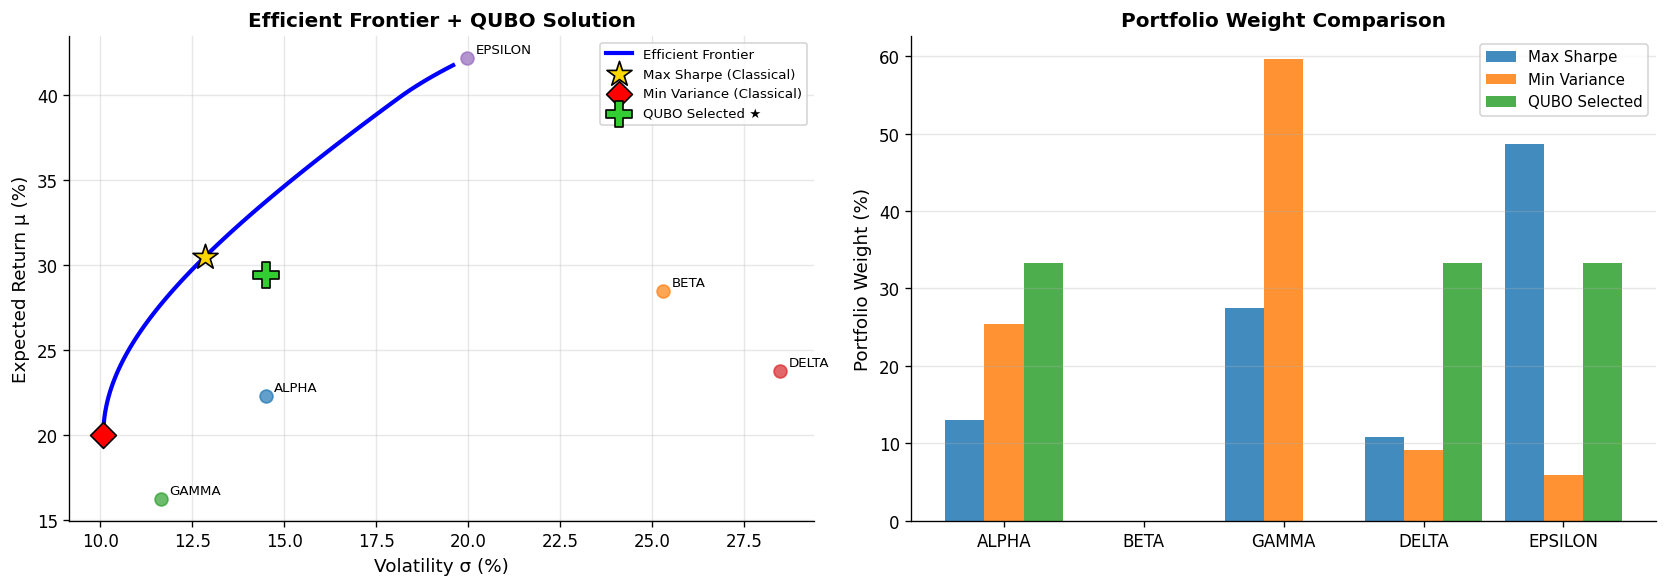

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 8.1 Efficient Frontier ────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(ef_stds * 100, ef_returns * 100, "b-", lw=2.5, label="Efficient Frontier")
ax1.scatter(ef_stds[max_idx]*100,    ef_returns[max_idx]*100,
            marker="*", s=250, color="gold", edgecolors="k", zorder=6, label="Max Sharpe (Classical)")
ax1.scatter(ef_stds[min_var_idx]*100, ef_returns[min_var_idx]*100,
            marker="D", s=120, color="red",  edgecolors="k", zorder=6, label="Min Variance (Classical)")
ax1.scatter(std_q*100, ret_q*100,
            marker="P", s=250, color="limegreen", edgecolors="k", zorder=6, label="QUBO Selected ★")

for i in range(N_ASSETS):
    ax1.scatter(np.sqrt(cov_ann[i,i])*100, mu_ann[i]*100, s=60, alpha=0.7)
    ax1.annotate(ASSET_NAMES[i], (np.sqrt(cov_ann[i,i])*100, mu_ann[i]*100),
                 xytext=(5, 3), textcoords="offset points", fontsize=8)

ax1.set_xlabel("Volatility σ (%)", fontsize=11)
ax1.set_ylabel("Expected Return μ (%)", fontsize=11)
ax1.set_title("Efficient Frontier + QUBO Solution", fontsize=12, fontweight="bold")
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# ── 8.2 Weight comparison ─────────────────────────────────────────────────
ax2 = axes[1]
x_pos = np.arange(N_ASSETS)
width = 0.28

ax2.bar(x_pos - width,   msr_w * 100, width, label="Max Sharpe",   color="#1f77b4", alpha=0.85)
ax2.bar(x_pos,           mvp_w * 100, width, label="Min Variance", color="#ff7f0e", alpha=0.85)
ax2.bar(x_pos + width, w_qubo * 100, width, label="QUBO Selected", color="#2ca02c", alpha=0.85)

ax2.set_xticks(x_pos); ax2.set_xticklabels(ASSET_NAMES)
ax2.set_ylabel("Portfolio Weight (%)", fontsize=11)
ax2.set_title("Portfolio Weight Comparison", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()


---
## Section 9 · Classical vs Quantum Formulation — Side-by-Side Comparison

| Aspect | Classical (SciPy SLSQP) | Quantum (QUBO / Qiskit) |
|---|---|---|
| Variable type | Continuous $w_i \in [0,1]$ | Binary $x_i \in \{0,1\}$ |
| Solver | Gradient-based (SLSQP) | Eigensolver / QAOA / VQE |
| Constraint handling | Explicit inequality/equality | Penalty terms in objective |
| Scalability | $O(n^3)$ (matrix ops) | $O(2^n)$ classical, $O(\text{poly})$ quantum |
| Cardinality constraint | Requires integer programming | Native binary formulation |
| Optimality | Global (convex QP) | Approximate (NISQ) / Exact (fault-tolerant) |
| Quantum advantage | ✗ (none for this size) | ✓ potential for large $n$ |

### Key Insight

For $n = 5$ assets, brute-force enumeration finds the exact answer in $\binom{5}{3} = 10$ evaluations — no quantum advantage.

**The advantage emerges at scale:** For $n = 50$ assets selecting $k = 20$, we have $\binom{50}{20} \approx 4.7 \times 10^{13}$ combinations. Classical integer solvers struggle; QAOA/VQE can find near-optimal solutions in $O(\text{poly}(n))$ circuit evaluations.


In [11]:
# ── Summary comparison table ──────────────────────────────────────────────
results_table = pd.DataFrame({
    "Portfolio":     ["Max Sharpe (Classical)", "Min Variance (Classical)", f"QUBO (select {BUDGET} assets)"],
    "Return (%)":    [portfolio_return(msr_w, mu_ann)*100,
                      portfolio_return(mvp_w, mu_ann)*100,
                      ret_q*100],
    "Volatility (%)": [np.sqrt(portfolio_variance(msr_w, cov_ann))*100,
                       np.sqrt(portfolio_variance(mvp_w, cov_ann))*100,
                       std_q*100],
    "Sharpe Ratio":  [portfolio_sharpe(msr_w, mu_ann, cov_ann),
                      portfolio_sharpe(mvp_w, mu_ann, cov_ann),
                      shr_q],
    "Assets Used":   [f"{sum(msr_w>0.01)}/5",
                      f"{sum(mvp_w>0.01)}/5",
                      f"{BUDGET}/5"],
}).set_index("Portfolio").round(3)

print("\n" + "="*70)
print("FINAL COMPARISON TABLE")
print("="*70)
print(results_table.to_string())



FINAL COMPARISON TABLE
                          Return (%)  Volatility (%)  Sharpe Ratio Assets Used
Portfolio                                                                     
Max Sharpe (Classical)        30.456          12.834         2.139         4/5
Min Variance (Classical)      19.981          10.077         1.685         4/5
QUBO (select 3 assets)        29.398          14.516         1.819         3/5


---
## Section 10 · References

1. Markowitz, H. (1952). *Portfolio Selection*. Journal of Finance, 7(1), 77–91.
2. Orús, R., Mugel, S., & Lizaso, E. (2019). *Quantum computing for finance: Overview and prospects*. Reviews in Physics, 4, 100028.
3. Mugel, S. et al. (2022). *Dynamic portfolio optimization with real datasets using quantum processors*. Physical Review Research, 4(1).
4. Qiskit Finance Documentation. https://qiskit-community.github.io/qiskit-finance/
5. Qiskit Optimization Documentation. https://qiskit-community.github.io/qiskit-optimization/
6. IBM Quantum (2024). *Qiskit 1.x Migration Guide*. https://docs.quantum.ibm.com/

## Section 11 · Future Improvements

- Replace `NumPyMinimumEigensolver` with QAOA/VQE (see Notebook 2_1).
- Extend to multi-period rebalancing with transaction cost penalties.
- Add sector constraints: $\sum_{i \in S} x_i \leq k_S$ for each sector $S$.
- Implement Robust Markowitz with uncertainty sets on $oldsymbol{\mu}$ and $oldsymbol{\Sigma}$.
- Scale to $n > 20$ assets using warm-start QAOA.
